# APPLES

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### DATA

In [2]:
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 10854 rows
                                   Asset_A    Bid_A    Ask_A   Asset_B  \
timestamp                                                                
2025-01-02 10:20:10.133000+00:00  0.621755  0.62171  0.62180  0.561855   
2025-01-02 10:25:55.560000+00:00  0.621930  0.62188  0.62198  0.561855   
2025-01-02 10:32:05.618000+00:00  0.621680  0.62163  0.62173  0.561780   

                                    Bid_B    Ask_B     Log_A     Log_B  \
timestamp                                                                
2025-01-02 10:20:10.133000+00:00  0.56179  0.56192 -0.475209 -0.576511   
2025-01-02 10:25:55.560000+00:00  0.56179  0.56192 -0.474928 -0.576511   
2025-01-02 10:32:05.618000+00:00  0.56170  0.56186 -0.475330 -0.576645   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2025-01-02 10:20:10.133000+00:00  0.000265  0.000027          0.723758   
2025-01-02 10:25:55

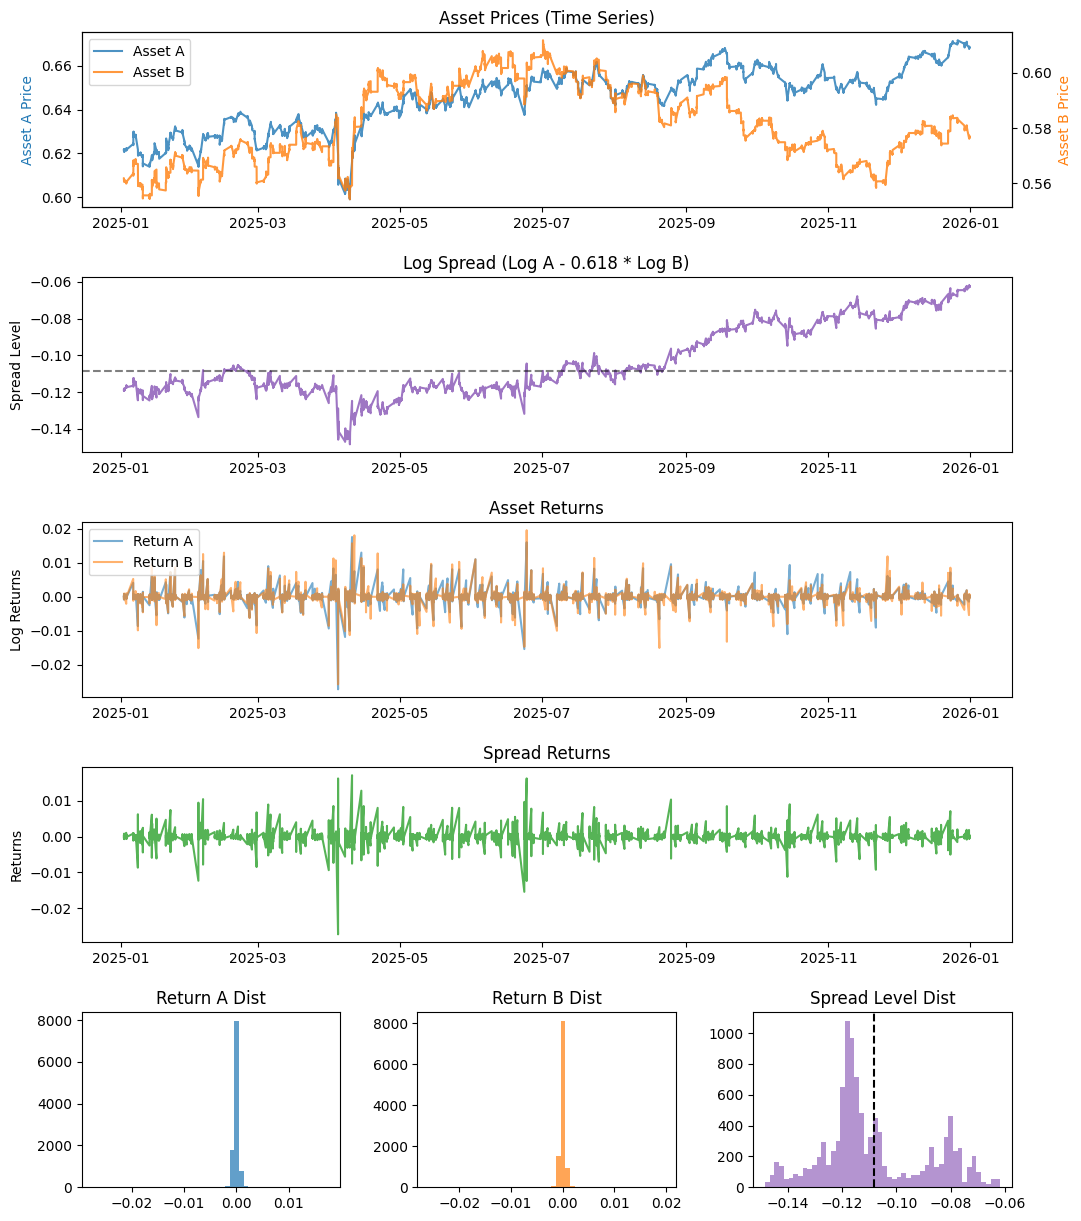

In [3]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(10, 14))
df = builder.build(my_files)

print(df.head(3))
print("\nColumns:", list(df.columns))
print(f"Median half-spread (bps) — A: {df['HalfSpread_A_bps'].median():.2f} | "
      f"B: {df['HalfSpread_B_bps'].median():.2f}")

# Call the new diagnostic plotter after the data is built
builder.plot_diagnostics()

### SCREENER

             COINTEGRATION SCREENER REPORT              
Full-sample:
  P-value:    0.9830
  Half-life:  808.8 bars
  Beta:       0.6185

Rolling (2000-bar windows, step 200, 45 windows):
  Fraction p < 0.05:   4.4%
  Fraction p < 0.10:   6.7%
  Half-life median:    42.4 bars (IQR 31–64)
  Beta mean:           0.6844
  Beta std:            0.2936
  Beta range:          [0.0193, 1.3377]
--------------------------------------------------------
Interpretation: rarely cointegrated. If trading anyway, the case must rest on something other than static coint.
  + Hedge ratio drifts materially — rolling beta recommended.



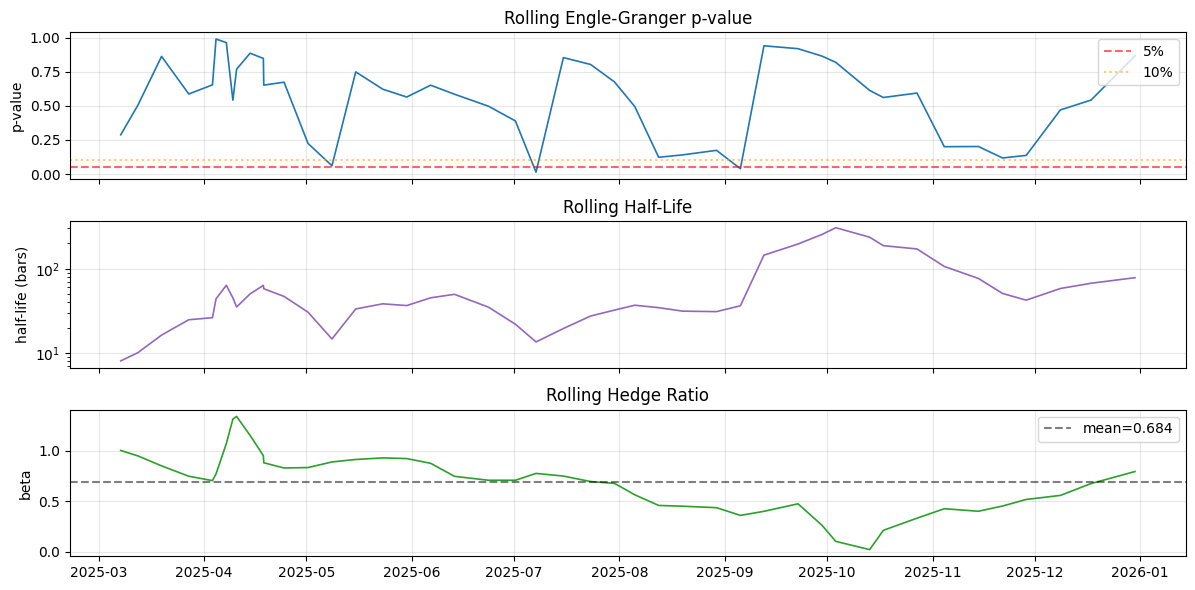

In [4]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### ENGINE

train_days=30 | coint_window=558 | z_window=250
[ROLLING] Cointegration Fitted over 558-bar window | Last Beta: 0.9642 | Last Alpha: 0.0803 | Valid rows: 591
Markov Fitted (k=2) | Danger Var: 2312.72 | Safe Var: 13.53
[2025-02-13] Beta: 0.9642 | GARCH: 7.59 | AR: 0.9256
[ROLLING] Cointegration Fitted over 558-bar window | Last Beta: 0.9287 | Last Alpha: 0.0603 | Valid rows: 581
Markov Fitted (k=2) | Danger Var: 2438.62 | Safe Var: 13.82
[ROLLING] Cointegration Fitted over 558-bar window | Last Beta: 1.0259 | Last Alpha: 0.1162 | Valid rows: 583
Markov Fitted (k=2) | Danger Var: 2600.52 | Safe Var: 14.15
[ROLLING] Cointegration Fitted over 558-bar window | Last Beta: 1.0583 | Last Alpha: 0.1349 | Valid rows: 508
Markov Fitted (k=2) | Danger Var: 3397.82 | Safe Var: 13.67
[ROLLING] Cointegration Fitted over 558-bar window | Last Beta: 1.1124 | Last Alpha: 0.1660 | Valid rows: 482
Markov Fitted (k=2) | Danger Var: 3106.05 | Safe Var: 13.60
[ROLLING] Cointegration Fitted over 558-bar windo

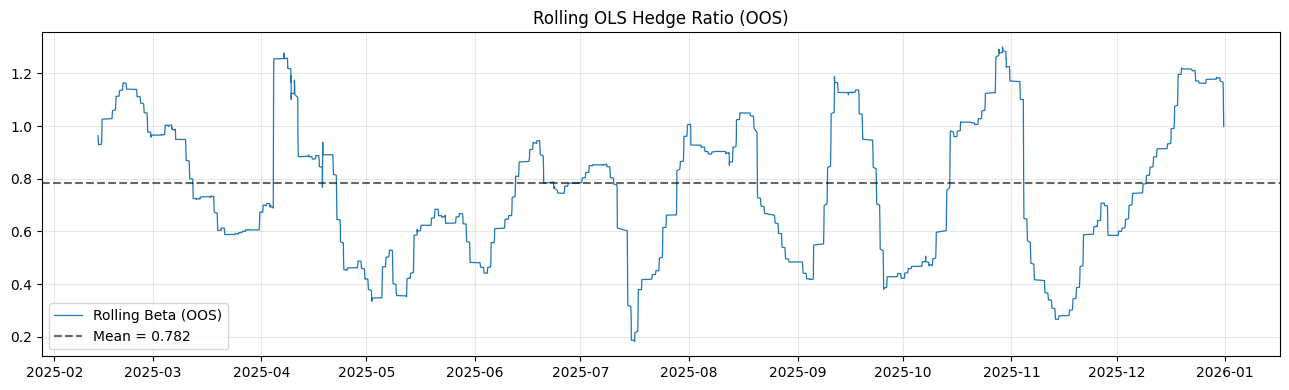

Beta range: [0.182, 1.300]
Beta std:    0.2615


In [5]:
live_trading_data, df_params = ENGINE.walk_forward(df, train_days=30, z_window=250)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(live_trading_data.index, live_trading_data['Beta'],
        color='tab:blue', linewidth=0.9, label='Rolling Beta (OOS)')
ax.axhline(live_trading_data['Beta'].mean(), color='black', linestyle='--',
           alpha=0.6, label=f"Mean = {live_trading_data['Beta'].mean():.3f}")
ax.set_title("Rolling OLS Hedge Ratio (OOS)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Beta range: [{live_trading_data['Beta'].min():.3f}, {live_trading_data['Beta'].max():.3f}]")
print(f"Beta std:    {live_trading_data['Beta'].std():.4f}")

### BACKTESTER

In [6]:
import importlib
import backtester  

importlib.reload(backtester)
from backtester import BACKTESTER

bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=1.25,
    exit_z=0.0,
    danger_threshold=0.7,          # fixed: was 1.1 which never triggered
    ar_limit=0.995,
    fee_bps=0.5,
    stop_loss_bps=100.0,
    take_profit_bps=25.0,
    max_hold_bars=150,
    slippage_mode='half_spread',   # realistic execution cost
)

### TEARSHEET


                   INSTITUTIONAL PERFORMANCE REPORT                   
Metric                 | Adaptive     | Static Base  | Cash        
----------------------------------------------------------------------
Total Return (Bps)     | -43.99       | 2710.26      | 0.00        
Annual Vol (Bps)       | 527.23       | 731.23       | 0.00        
Sharpe Ratio           | -0.09        | 4.08         | 0.00        
Sortino Ratio          | -0.08        | 4.17         | nan         
Max Drawdown (Bps)     | -470.85      | -146.70      | 0.00        
Calmar Ratio           | 0.09         | 18.47        | 0.00        
Win Rate               | 47.30%       | 50.52%       | 0.00%       
Profit Factor          | 0.99         | 1.34         | 0.00        



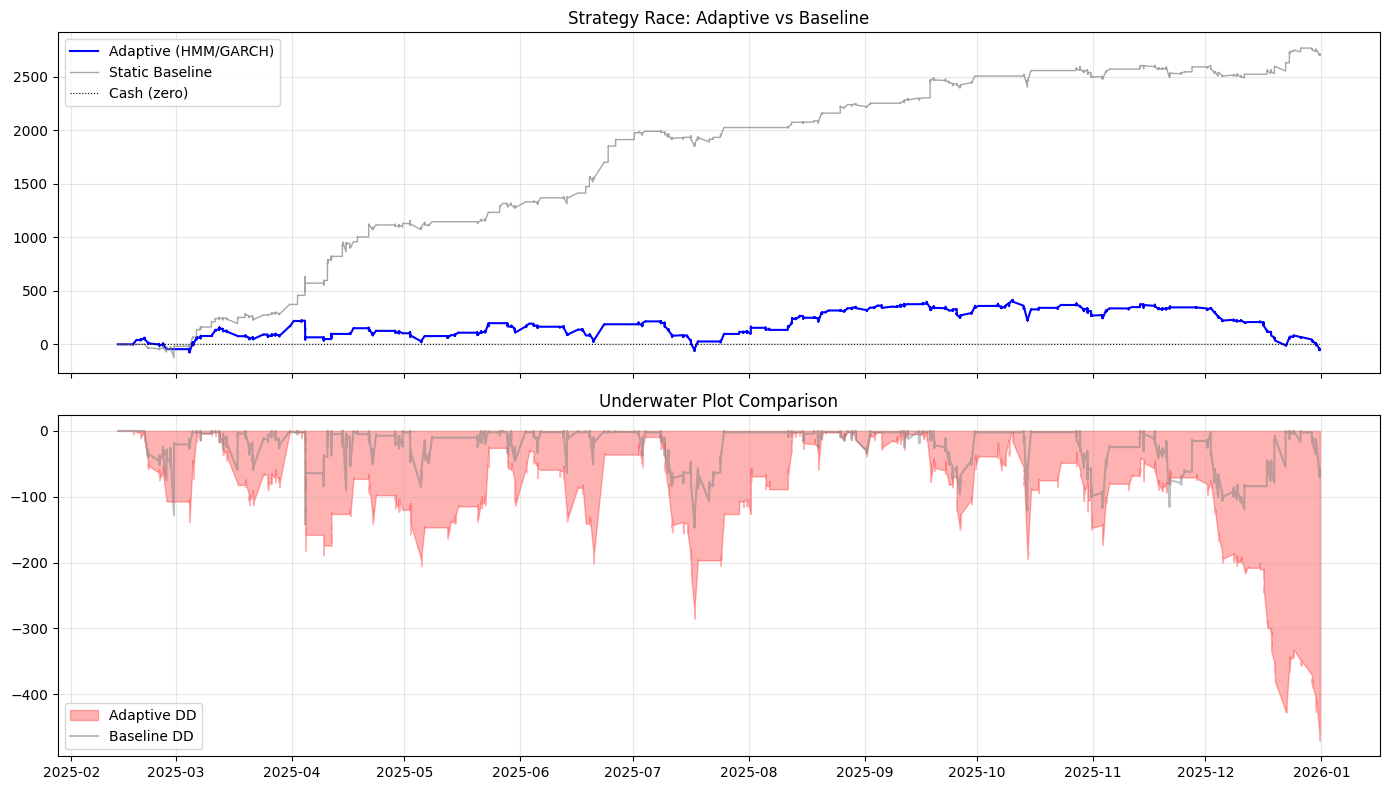

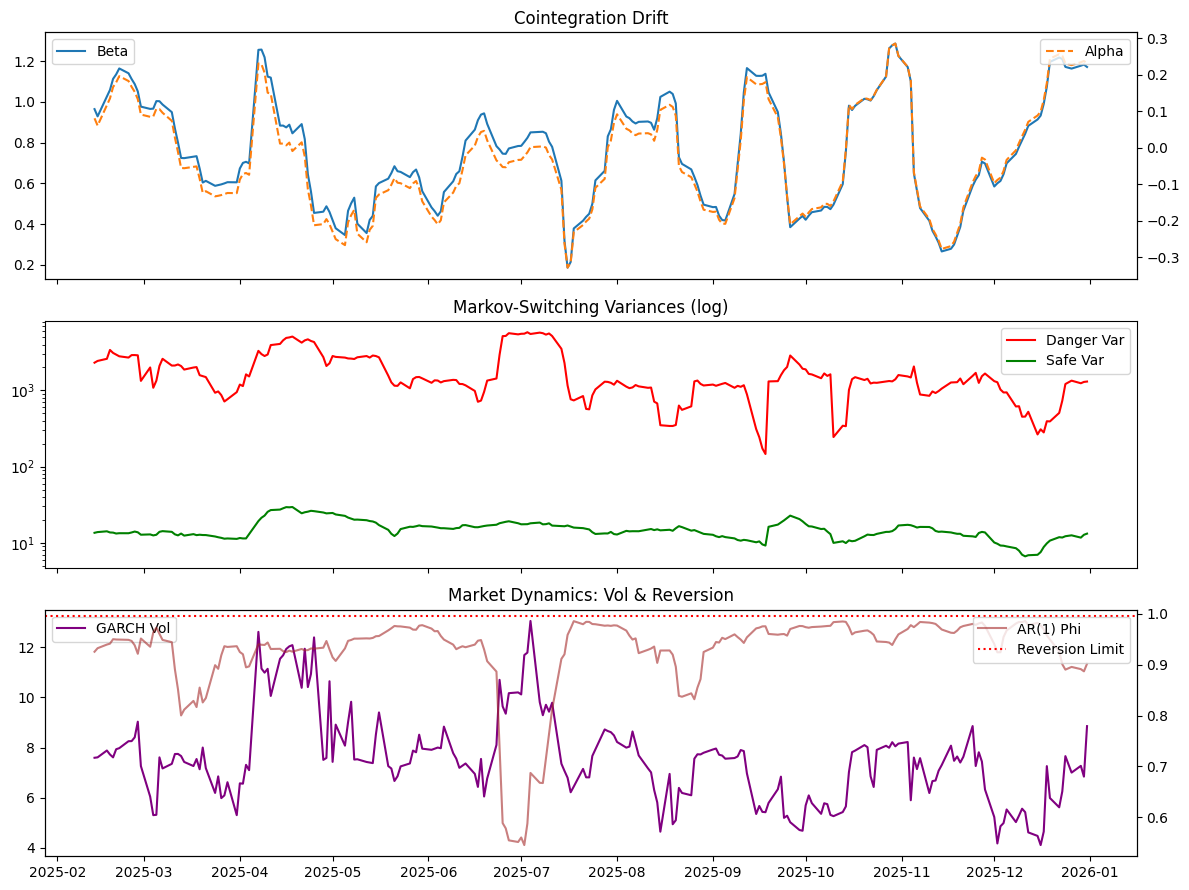

In [7]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_comparative_equity()
ts.plot_engine_parameters()

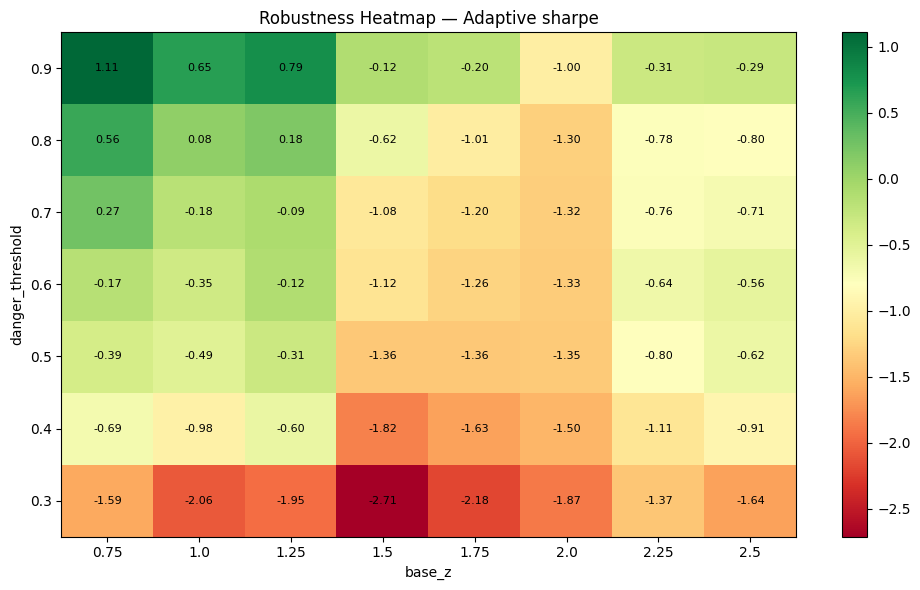


Top 5 (base_z, danger_threshold) by Sharpe:
0.9  0.75    1.108301
     1.25    0.787988
     1.00    0.651497
0.8  0.75    0.559169
0.7  0.75    0.268364
dtype: float64


In [8]:
heat_df = ts.plot_robustness_heatmap(
    engine_data=live_trading_data,
    base_z_grid=np.round(np.arange(0.75, 2.51, 0.25), 2),
    danger_grid=np.round(np.arange(0.3, 0.96, 0.1), 2),
    fixed_params={
        'exit_z': 0.0,
        'ar_limit': 0.995,
        'fee_bps': 0.5,
        'stop_loss_bps': 100.0,
        'take_profit_bps': 25.0,
        'max_hold_bars': 150,
        'slippage_mode': 'half_spread',
    },
    metric='sharpe',
)
print("\nTop 5 (base_z, danger_threshold) by Sharpe:")
print(heat_df.stack().sort_values(ascending=False).head(5))